# Logistic Regression

### Theory

* Learning about logistic regression as a method for classification (categorical data) <br>
* * Classification deals with determining which of a set of categories a new value will belong  <br>
* * --Ex: Binary classifications (two classes): <br>
				---- Spam vs not spam emails <br>
				---- Loan defaulting (yes/no) <br>
				---- Disease diagnosis <br>
* * --Can't use a normal linear regression model on binary groups, it won't lead to a good fit <br>
			----So we transform the linear regression line to a logistic regression curve (sigmoid) <br>
			----Sigmoid (aka Logistic) function takes in any value and outputs it to be between 0 and 1 <br>
			----Plugging the linear regression function into our z value within our logistic regression function leads to a probability from 0 to 1 of belonging in the 1 class (binary classification is 0 or 1) <br>
            ----We can then set a cutoff point (usually 0.5) and anything below that point results in class 0, anything above is class 1 <br>
    		----"If the probability is less than 50% (0.5 cutoff) which would fall below the cutoff point, then we will assign this data point to class 0" <br> <br>
* <b>Model Evaluation</b>
* * After you train a logistic regression model on the training data, you will evaluate your model's performance on test data <br>
-- Use a confusion matrix to evaluate the classification models

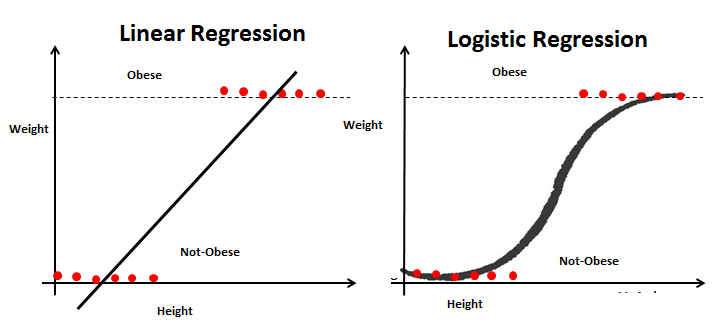

* <b>True Positive (TP)</b> <br>
-- We predict yes, and the actual result is yes
* <b>True Negative (TN)</b> <br>
-- We predict no, and the actual result is no
* <b>False Positive (FP, Type 1 Error)</b> <br>
-- We predict yes, and the actual result is no
* <b>False Negative (FN, Type 2 Error)</b>  <br>
-- We predict no, and the actual result is yes

<div>
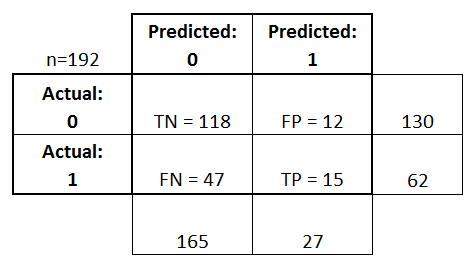
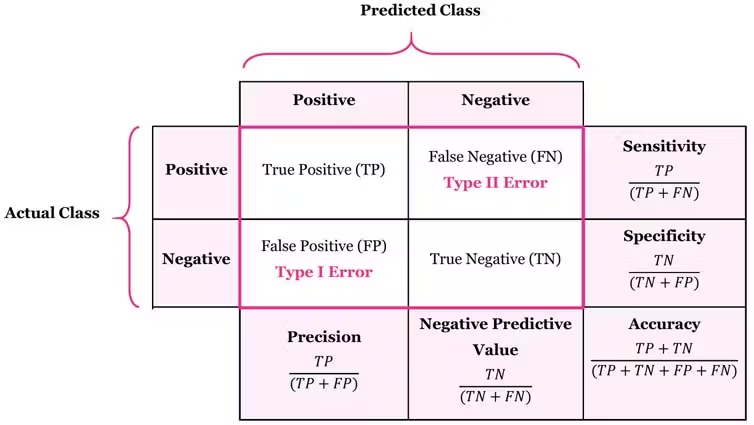
</div>

* <b>Accuracy</b> <br>
-- Overall, how correct is the fit of the model? <br>
-- (TP + TN) / Total
* <b>Misclassification Rate (Error Rate)</b> <br>
-- Overall, how often is the model wrong? <br>
-- (FP + FN) / Total

# Logistic Regression Process

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('titanic_train.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### EDA

In [5]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: xlabel='Survived', ylabel='count'>

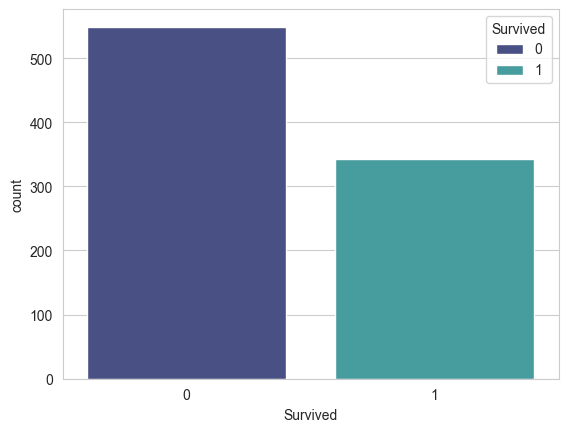

In [6]:
sns.set_style('whitegrid')

#Getting a ratio of the target variable (Survived vs not survived)
sns.countplot(x='Survived', data=train, hue='Survived', palette='mako')

<Axes: xlabel='Survived', ylabel='count'>

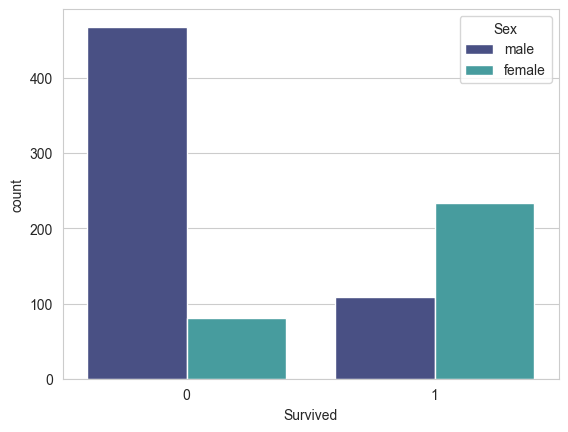

In [7]:
sns.set_style('whitegrid')

#Getting a ratio of the target variable (Survived vs not survived) - Hue by Sex column
sns.countplot(x='Survived', data=train, hue='Sex', palette='mako')

#From our training data split (regarding those who died) we see that around 4x as many men died as women
# and also that (regarding those who survived) around twice as many women survived as men did

<Axes: xlabel='Survived', ylabel='count'>

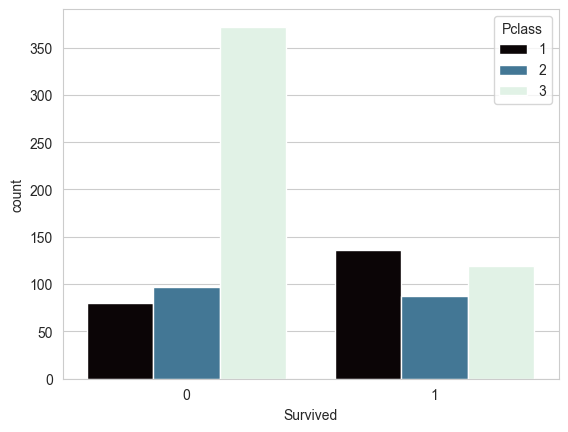

In [8]:
sns.set_style('whitegrid')

#Getting a ratio of the target variable (Survived vs not survived) - Hue by Sex column
sns.countplot(x='Survived', data=train, hue='Pclass', palette='mako')

#Countplot below shows that you were much more likely to die if you were in third class (cheapest tickets)
#And also those in first class represented the largest group of those who survived

<Axes: xlabel='Age', ylabel='Count'>

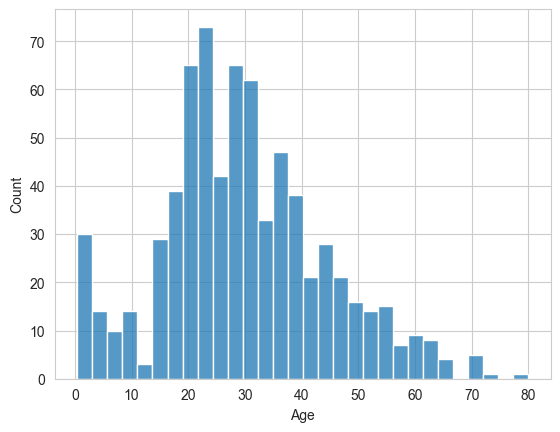

In [9]:
#We see a bi-modal distribution, with large groups of younger people around age groups 20 or 30, and with older groups 
#being less heavily represented in the graph
sns.histplot(train['Age'].dropna(), kde=False, bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

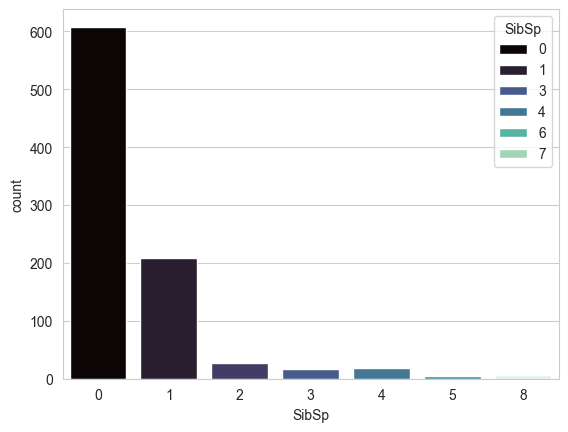

In [10]:
sns.countplot(x='SibSp', data=train, hue='SibSp', palette='mako')

#We see that most people on board did not have a sibling or a spouse onboard the ship

<Axes: xlabel='Fare', ylabel='Count'>

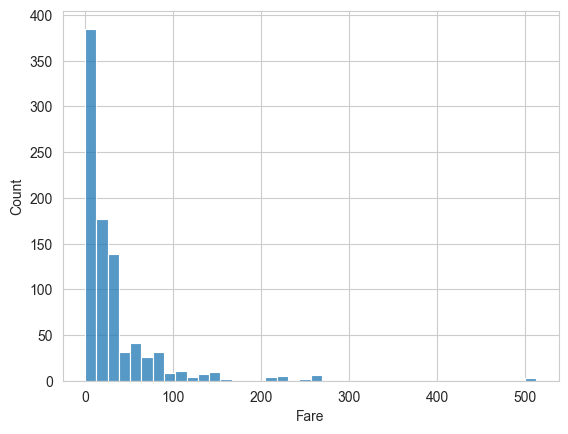

In [11]:
sns.histplot(train['Fare'], kde=False, bins=40)

#We see that the majority of fares were in the left side of our distribution plot, meaning that the majority of people
#bought cheaper tickets

### Dealing with missing data - Imputing Values 

<Axes: >

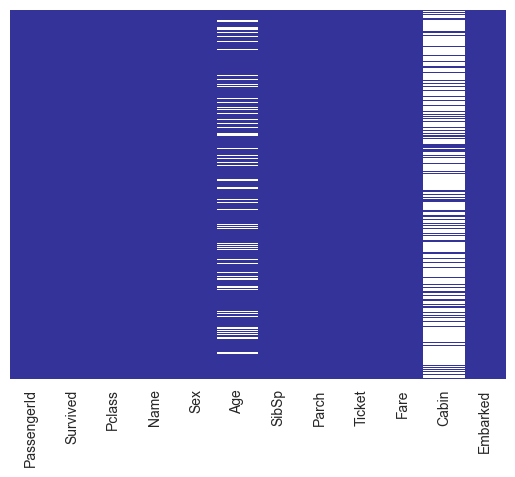

In [12]:
#Visualizing the missing values, and for which columns (missing a lot of cabin, age, and some embarked)
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='terrain')

<Axes: xlabel='Pclass', ylabel='Age'>

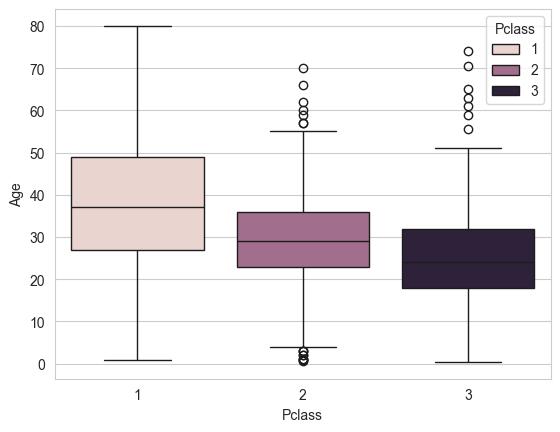

In [13]:
sns.boxplot(x='Pclass', y='Age', data=train, hue='Pclass')

#We see an association between age and Pclass, meaning that as you age, you are more likely able to buy more expensive tickets
#It looks like a good idea to use this as a means to further our imputation as opposed to imputing with just the average age

In [14]:
median_ages = train.groupby('Pclass')['Age'].median()

def impute_age(row):
    if pd.isnull(row['Age']):
        return median_ages[row['Pclass']]
    else:
        return row['Age']

train['Age'] = train.apply(impute_age, axis=1)

<Axes: >

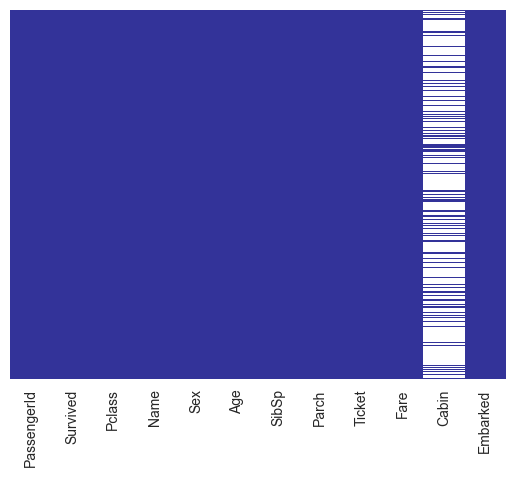

In [15]:
#Visualizing missing values after imputing the missing Age values
#Still missing the majority of Cabin column, likely best to drop entire column
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='terrain')

In [16]:
#Dropping Cabin column due to the amount of missing values
train.drop('Cabin', axis=1, inplace=True)

### Dealing with Categorical Variables (Dummy Variables/ One-Hot Encoding)

* A machine learning algorithm can't intake a categorical variables with several categories and immediately know what to do with those strings. We need to convert those values to numeric equivalents so the machine learning algorithm can properly work with it (Converting male/ female to 0 or 1)

In [17]:
#pd.get_dummies outputs a DF with each category as it's own column, but this leads to an issue with Multicollinearity
#This is because if the algorithm sees that for each row, if Female=0, then it knows that Male automatically equals 1 and vice versa
#drop_first=True gets rid of the first column, and then produces an output we can feed into the model
sex = pd.get_dummies(train['Sex'], drop_first=True, dtype=int)
sex.head()

,male
0,1
1,0
2,0
3,0
4,1


In [18]:
#Dropping "C" column to eliminate the Multicollinearity
embark = pd.get_dummies(train['Embarked'], drop_first=True, dtype=int)
embark.head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [19]:
#Concatenating DFs (original train DF, sex DF, and embark DF), axis=1 because we want to add them in as new columns
train = pd.concat([train, sex, embark], axis=1)
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,0,0


* Now that we have encoded the Sex and Embark columns, which have each been added as new columns, we no longer need the original Sex and Embark columns.
* Also dropping additional columns that we do not need such as PassengerId, Name, and Ticket

In [20]:
train.drop(['PassengerId', 'Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)
train

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,0,1
887,1,1,19.0,0,0,30.0000,0,0,1
888,0,3,24.0,1,2,23.4500,0,0,1
889,1,1,26.0,0,0,30.0000,1,0,0
